# Wrangling and Analysing WeRateDogs Twitter Data
**Irene Undiandeye**

## Introduction

WeRateDogs is a Twitter account that rates people's dogs with humorous comments and ratings that usually exceed 10 out of 10. This project gathers data about its tweets from three sources, assesses the data for quality and tidiness problems, cleans it into a single master dataset, and analyses it to find out what drives engagement and how the account's ratings have changed over time.

## Contents

1. Gathering data
2. Assessing data
3. Cleaning data
4. Storing data
5. Analysing and visualising data
6. Conclusions

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

os.makedirs('images', exist_ok=True)
plt.rcParams['figure.dpi'] = 110

## 1. Gathering Data

The project uses three sources. The **Twitter archive** (`twitter_archive_enhanced.csv`) contains the text, rating, dog name and dog stage of 2,356 tweets. The **image predictions** (`image_predictions.tsv`) contain the top three breed predictions from a neural network applied to each tweet's photo; this file was originally downloaded programmatically with the Requests library. The **tweet engagement data** (`tweet_json.txt`) contains retweet and favourite counts collected through the Twitter API with Tweepy.

The Twitter API is no longer freely available, so the notebook loads the saved copies of the downloaded files. The original collection code is kept below, commented out, to document how the data was gathered. Note that only 873 of the 2,356 tweets could be retrieved from the API at collection time, as many had been deleted.

In [2]:
# Original download of the image predictions with Requests:
# import requests
# url = 'https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv'
# with open('image_predictions.tsv', 'wb') as f:
#     f.write(requests.get(url).content)

# Original collection of engagement data with Tweepy (credentials removed):
# import tweepy
# auth = tweepy.OAuthHandler(consumer_key, consumer_secret)
# auth.set_access_token(access_token, access_token_secret)
# api = tweepy.API(auth, wait_on_rate_limit=True)
# with open('tweet_json.txt', 'w', encoding='utf8') as f:
#     for tweet_id in archive['tweet_id']:
#         try:
#             tweet = api.get_status(tweet_id, tweet_mode='extended')
#             f.write(json.dumps(tweet._json) + '\n')
#         except Exception:
#             pass

In [3]:
# keep_default_na=False preserves the literal text 'None', so the raw data is seen as it really is
archive = pd.read_csv('twitter_archive_enhanced.csv', keep_default_na=False, na_values=[''])
predictions = pd.read_csv('image_predictions.tsv', sep='\t')

with open('tweet_json.txt', encoding='utf8') as f:
    api_tweets = [json.loads(line) for line in f]
engagement = pd.DataFrame([{
    'tweet_id': t['id_str'],
    'retweet_count': t['retweet_count'],
    'favorite_count': t['favorite_count'],
} for t in api_tweets])

print(f"Archive: {archive.shape}, predictions: {predictions.shape}, engagement: {engagement.shape}")

Archive: (2356, 17), predictions: (2075, 12), engagement: (873, 3)


## 2. Assessing Data

### 2.1 Twitter archive

In [4]:
archive.sample(5, random_state=1)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
1204,716080869887381504,NaN,NaN,2016-04-02 01:52:38 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Here's a super majestic doggo and a sunset 11/...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/716080869...,11,10,None,doggo,None,None,None
50,882627270321602560,NaN,NaN,2017-07-05 15:48:34 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Stanley. He has his first swim lesson ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/882627270...,13,10,Stanley,None,None,None,None
812,771136648247640064,NaN,NaN,2016-09-01 00:04:38 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Dixie. She wants to be a ship captain....,NaN,NaN,NaN,https://twitter.com/dog_rates/status/771136648...,11,10,Dixie,None,None,None,None
1197,717009362452090881,NaN,NaN,2016-04-04 15:22:08 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Smokey. He's having some sort of exist...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/717009362...,10,10,Smokey,None,None,pupper,None
920,756303284449767430,NaN,NaN,2016-07-22 01:42:09 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Pwease accept dis rose on behalf of dog. 11/10...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/756303284...,11,10,None,None,None,None,None


In [5]:
archive.info()

<class 'pandas.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   str    
 4   source                      2356 non-null   str    
 5   text                        2356 non-null   str    
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    str    
 9   expanded_urls               2297 non-null   str    
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        2356 non-null   str    
 13  doggo                       2356 non-null   

In [6]:
print(f"Retweets: {archive['retweeted_status_id'].notna().sum()}")
print(f"Replies: {archive['in_reply_to_status_id'].notna().sum()}")
print(f"Tweets with no image prediction: {(~archive['tweet_id'].isin(predictions['tweet_id'])).sum()}")

Retweets: 181
Replies: 78
Tweets with no image prediction: 281


In [7]:
lowercase_names = archive.loc[archive['name'].str.match(r'^[a-z]'), 'name']
print(f"'None' as a name: {(archive['name'] == 'None').sum()}")
print(f"Lowercase words recorded as names: {len(lowercase_names)}")
lowercase_names.value_counts().head(10)

'None' as a name: 745
Lowercase words recorded as names: 109


name
a           55
the          8
an           7
very         5
quite        4
one          4
just         4
not          2
mad          2
actually     2
Name: count, dtype: int64

In [8]:
archive['rating_denominator'].value_counts()

rating_denominator
10     2333
11        3
50        3
20        2
80        2
0         1
15        1
70        1
7         1
150       1
170       1
90        1
40        1
130       1
110       1
16        1
120       1
2         1
Name: count, dtype: int64

In [9]:
pd.set_option('display.max_colwidth', 120)
decimal_ratings = archive[archive['text'].str.contains(r'\d+\.\d+/\d+')]
decimal_ratings[['text', 'rating_numerator', 'rating_denominator']]

,text,rating_numerator,rating_denominator
45,"This is Bella. She hopes her smile made you smile. If not, she is also offering you her favorite monkey. 13.5/10 htt...",5,10
340,"RT @dog_rates: This is Logan, the Chow who lived. He solemnly swears he's up to lots of good. H*ckin magical af 9.75...",75,10
695,"This is Logan, the Chow who lived. He solemnly swears he's up to lots of good. H*ckin magical af 9.75/10 https://t.c...",75,10
763,This is Sophie. She's a Jubilant Bush Pupper. Super h*ckin rare. Appears at random just to smile at the locals. 11.2...,27,10
1689,I've been told there's a slight possibility he's checking his mirror. We'll bump to 9.5/10. Still a menace,5,10
1712,Here we have uncovered an entire battalion of holiday puppers. Average of 11.26/10 https://t.co/eNm2S6p9BD,26,10


In [10]:
archive.loc[archive['rating_denominator'] != 10, ['text', 'rating_numerator', 'rating_denominator']].head(8)

,text,rating_numerator,rating_denominator
313,"@jonnysun @Lin_Manuel ok jomny I know you're excited but 960/00 isn't a valid rating, 13/10 is tho",960,0
342,@docmisterio account started on 11/15/15,11,15
433,The floofs have been released I repeat the floofs have been released. 84/70 https://t.co/NIYC820tmd,84,70
516,Meet Sam. She smiles 24/7 &amp; secretly aspires to be a reindeer. \nKeep Sam smiling by clicking and sharing this l...,24,7
784,"RT @dog_rates: After so many requests, this is Bretagne. She was the last surviving 9/11 search dog, and our second ...",9,11
902,Why does this never happen at my front door... 165/150 https://t.co/HmwrdfEfUE,165,150
1068,"After so many requests, this is Bretagne. She was the last surviving 9/11 search dog, and our second ever 14/10. RIP...",9,11
1120,Say hello to this unbelievably well behaved squad of doggos. 204/170 would try to pet all at once https://t.co/yGQI3...,204,170


In [11]:
archive['source'].value_counts()

source
<a href="http://twitter.com/download/iphone" rel="nofollow">Twitter for iPhone</a>     2221
<a href="http://vine.co" rel="nofollow">Vine - Make a Scene</a>                          91
<a href="http://twitter.com" rel="nofollow">Twitter Web Client</a>                       33
<a href="https://about.twitter.com/products/tweetdeck" rel="nofollow">TweetDeck</a>      11
Name: count, dtype: int64

In [12]:
stage_cols = ['doggo', 'floofer', 'pupper', 'puppo']
print(archive[stage_cols].apply(lambda c: c.value_counts()).fillna(0).astype(int))
print(f"\nTweets with more than one stage: {(archive[stage_cols] != 'None').sum(axis=1).gt(1).sum()}")

         doggo  floofer  pupper  puppo
None      2259     2346    2099   2326
doggo       97        0       0      0
floofer      0       10       0      0
pupper       0        0     257      0
puppo        0        0       0     30

Tweets with more than one stage: 14


### 2.2 Image predictions

In [13]:
predictions.sample(5, random_state=1)

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
724,686034024800862208,https://pbs.twimg.com/media/CYVIToGWQAAEZ_y.jpg,1,Great_Dane,0.236920,True,Irish_wolfhound,0.117608,True,Greater_Swiss_Mountain_dog,0.103900,True
348,672481316919734272,https://pbs.twimg.com/media/CVUiMUeW4AEQgkU.jpg,1,Border_collie,0.599454,True,collie,0.106227,True,Shetland_sheepdog,0.094465,True
102,667801013445750784,https://pbs.twimg.com/media/CUSBemVUEAAn-6V.jpg,1,flat-coated_retriever,0.508392,True,Chesapeake_Bay_retriever,0.262239,True,curly-coated_retriever,0.048920,True
1081,718246886998687744,https://pbs.twimg.com/media/Cfe5tLWXEAIaoFO.jpg,1,Chihuahua,0.354488,True,carton,0.159672,False,Siberian_husky,0.057498,True
1823,834931633769889797,https://pbs.twimg.com/media/C5ZF4p-XEAEmApg.jpg,1,ice_bear,0.330573,False,soft-coated_wheaten_terrier,0.196476,True,Irish_terrier,0.073096,True


In [14]:
any_dog = predictions[['p1_dog', 'p2_dog', 'p3_dog']].any(axis=1)
all_dog = predictions[['p1_dog', 'p2_dog', 'p3_dog']].all(axis=1)
print(f"Images where no prediction is a dog: {(~any_dog).sum()}")
print(f"Images where at least one prediction is a dog: {any_dog.sum()}")
print(f"Images where all three predictions are dogs: {all_dog.sum()}")
print(f"Duplicate image URLs: {predictions['jpg_url'].duplicated().sum()}")
predictions['p1'].sample(8, random_state=2).tolist()

Images where no prediction is a dog: 324
Images where at least one prediction is a dog: 1751
Images where all three predictions are dogs: 1243
Duplicate image URLs: 66


['Pembroke',
 'Saluki',
 'Great_Pyrenees',
 'miniature_pinscher',
 'web_site',
 'standard_poodle',
 'pug',
 'beagle']

### 2.3 Engagement data

In [15]:
engagement.info()
print(f"\nRetweets among the API records: {sum('retweeted_status' in t for t in api_tweets)}")

<class 'pandas.DataFrame'>
RangeIndex: 873 entries, 0 to 872
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   tweet_id        873 non-null    str  
 1   retweet_count   873 non-null    int64
 2   favorite_count  873 non-null    int64
dtypes: int64(2), str(1)
memory usage: 20.6 KB

Retweets among the API records: 148


### 2.4 Summary of issues

**Quality issues**

1. *Archive:* 181 rows are retweets rather than original ratings.
2. *Archive:* 78 rows are replies rather than original ratings.
3. *Archive:* 281 tweets have no image and therefore no breed prediction.
4. *Archive:* the `name` column contains "None" and lowercase words that are not names, such as "a", "the" and "such".
5. *Archive:* decimal ratings were extracted incorrectly, for example 13.5/10 recorded as 5/10.
6. *Archive:* some ratings were taken from the wrong fraction in the text (such as "24/7" or "9/11"), and group ratings use denominators other than 10 (such as 84/70), so ratings are not comparable.
7. *Archive:* `timestamp` is stored as text rather than a date.
8. *Archive:* `source` contains full HTML tags instead of the source name.
9. *Archive:* missing dog stages are stored as the text "None" rather than as missing values.
10. *Predictions:* breed names are inconsistently formatted, with underscores and mixed capitalisation.
11. *Predictions:* some images are not dogs at all, and the most confident prediction is not always a dog even when a lower-ranked one is.
12. *Engagement:* `tweet_id` is stored as text while it is an integer in the other tables, and engagement data is only available for 873 tweets, a completeness issue that cannot be fixed and is documented as a limitation.

**Tidiness issues**

1. The dog stage is a single variable spread across four columns (`doggo`, `floofer`, `pupper`, `puppo`).
2. Each image's breed prediction is spread across nine columns; the analysis needs one predicted breed and its confidence.
3. The three tables all describe the same tweets and should form one master table.

## 3. Cleaning Data

In [16]:
archive_clean = archive.copy()
predictions_clean = predictions.copy()
engagement_clean = engagement.copy()

### Quality 1–3: Keep only original tweets with images

**Define:** remove retweets and replies, then keep only tweets with an image prediction. Retweets and replies must be filtered *before* the columns that identify them are dropped.

In [17]:
archive_clean = archive_clean[archive_clean['retweeted_status_id'].isna() & archive_clean['in_reply_to_status_id'].isna()]
archive_clean = archive_clean[archive_clean['tweet_id'].isin(predictions_clean['tweet_id'])]
archive_clean = archive_clean.drop(columns=['in_reply_to_status_id', 'in_reply_to_user_id', 'retweeted_status_id',
                                            'retweeted_status_user_id', 'retweeted_status_timestamp', 'expanded_urls'])

**Test:**

In [18]:
print(f"Rows remaining: {len(archive_clean):,}")
assert archive_clean['tweet_id'].isin(predictions_clean['tweet_id']).all()

Rows remaining: 1,971


### Quality 4: Invalid dog names

**Define:** replace "None" and lowercase non-names with missing values. Invalid names are set to missing, not replaced with invented names, because the true names are unknown.

In [19]:
invalid = archive_clean['name'].eq('None') | archive_clean['name'].str.match(r'^[a-z]')
archive_clean.loc[invalid, 'name'] = np.nan

**Test:**

In [20]:
assert not archive_clean['name'].dropna().str.match(r'^[a-z]').any()
assert not archive_clean['name'].eq('None').any()
print(f"Tweets with a valid name: {archive_clean['name'].notna().sum():,} of {len(archive_clean):,}")

Tweets with a valid name: 1,349 of 1,971


### Quality 5–6: Re-extract and standardise ratings

**Define:** re-extract every rating from the tweet text with a pattern that captures decimals. Where a tweet contains several fractions, use the last one whose denominator is a positive multiple of 10, which skips dates and phrases such as "24/7". Then convert every rating to a score out of 10 so that group ratings are comparable.

In [21]:
rating_pattern = re.compile(r'(\d+(?:\.\d+)?)/(\d+)')

def extract_rating(text):
    matches = [(float(n), int(d)) for n, d in rating_pattern.findall(text) if int(d) > 0 and int(d) % 10 == 0]
    return matches[-1] if matches else (np.nan, np.nan)

original_ratings = archive_clean[['rating_numerator', 'rating_denominator']].astype(float).copy()
ratings = archive_clean['text'].apply(extract_rating)
archive_clean['rating_numerator'] = ratings.str[0]
archive_clean['rating_denominator'] = ratings.str[1]
archive_clean['rating'] = archive_clean['rating_numerator'] / archive_clean['rating_denominator'] * 10

**Test:**

In [22]:
print(archive_clean.loc[archive_clean['text'].str.contains(r'\d+\.\d+/\d+'), ['rating_numerator', 'rating']])
print(f"\nTweets without a valid rating: {archive_clean['rating'].isna().sum()}")
changed = (archive_clean[['rating_numerator', 'rating_denominator']].ne(original_ratings).any(axis=1)
           & archive_clean['rating'].notna())
print(f"Ratings corrected: {changed.sum()}")
archive_clean['rating'].describe()

      rating_numerator  rating
45               13.50   13.50
695               9.75    9.75
763              11.27   11.27
1712             11.26   11.26

Tweets without a valid rating: 1
Ratings corrected: 30


count    1970.000000
mean       11.636944
std        40.886592
min         0.000000
25%        10.000000
50%        11.000000
75%        12.000000
max      1776.000000
Name: rating, dtype: float64

In [23]:
archive_clean.loc[archive_clean['rating'] > 15, ['text', 'rating']]

,text,rating
979,This is Atticus. He's quite simply America af. 1776/10 https://t.co/GRXwMxLBkh,1776.0
2074,After so many requests... here you go.\n\nGood dogg. 420/10 https://t.co/yfAAo1gdeY,420.0


Two ratings remain far above the usual range: 1776/10 for a dog dressed for the Fourth of July and 420/10 for Snoop Dogg. These are deliberate jokes rather than data errors, so they are kept in the dataset but flagged and excluded from the rating analysis.

In [24]:
archive_clean['rating_outlier'] = archive_clean['rating'] > 15

### Quality 7–8: Fix the timestamp and source

**Define:** convert `timestamp` to datetime and extract the readable source name from the HTML tag.

In [25]:
archive_clean['timestamp'] = pd.to_datetime(archive_clean['timestamp'])
archive_clean['source'] = archive_clean['source'].str.extract(r'>([^<]+)<', expand=False)

**Test:**

In [26]:
print(archive_clean['timestamp'].dtype)
archive_clean['source'].value_counts()

datetime64[us, UTC]


source
Twitter for iPhone    1932
Twitter Web Client      28
TweetDeck               11
Name: count, dtype: int64

### Quality 9 and Tidiness 1: One dog stage column

**Define:** treat "None" as missing and combine the four stage columns into a single `dog_stage` column. Tweets that mention more than one stage are labelled "multiple" rather than concatenated into values such as "doggopupper".

In [27]:
stages = archive_clean[stage_cols].replace('None', np.nan)
n_stages = stages.notna().sum(axis=1)
archive_clean['dog_stage'] = stages.bfill(axis=1).iloc[:, 0]
archive_clean.loc[n_stages > 1, 'dog_stage'] = 'multiple'
archive_clean = archive_clean.drop(columns=stage_cols)

**Test:**

In [28]:
archive_clean['dog_stage'].value_counts(dropna=False)

dog_stage
NaN         1668
pupper       201
doggo         63
puppo         22
multiple      10
floofer        7
Name: count, dtype: int64

### Quality 10–11 and Tidiness 2: One predicted breed per image

**Define:** for each image, take the most confident prediction that is a dog breed, with its confidence, and format breed names consistently. Images with no dog prediction keep a missing breed but are not deleted, because their ratings and engagement are still valid. This is less wasteful than keeping only images where all three predictions are dogs, which would discard over 500 tweets.

In [29]:
def best_dog(row):
    for k in (1, 2, 3):
        if row[f'p{k}_dog']:
            return pd.Series([row[f'p{k}'].replace('_', ' ').title(), row[f'p{k}_conf']])
    return pd.Series([np.nan, np.nan])

predictions_clean[['breed', 'breed_confidence']] = predictions_clean.apply(best_dog, axis=1)
predictions_clean = predictions_clean[['tweet_id', 'jpg_url', 'breed', 'breed_confidence']]

**Test:**

In [30]:
print(predictions_clean['breed'].notna().sum(), 'images with a predicted breed')
predictions_clean['breed'].value_counts().head()

1751 images with a predicted breed


breed
Golden Retriever      173
Labrador Retriever    113
Pembroke               96
Chihuahua              95
Pug                    65
Name: count, dtype: int64

### Quality 12 and Tidiness 3: Merge into one master table

**Define:** convert the engagement `tweet_id` to integer and merge all three tables on `tweet_id`. A left join keeps tweets without engagement data, so the rating analysis can use the full set.

In [31]:
engagement_clean['tweet_id'] = engagement_clean['tweet_id'].astype('int64')
master = (archive_clean
          .merge(predictions_clean, on='tweet_id', how='left')
          .merge(engagement_clean, on='tweet_id', how='left'))

**Test:**

In [32]:
assert master['tweet_id'].is_unique
print(f"Master rows: {len(master):,}")
print(f"With engagement data: {master['favorite_count'].notna().sum():,}")
master.info()

Master rows: 1,971
With engagement data: 650
<class 'pandas.DataFrame'>
RangeIndex: 1971 entries, 0 to 1970
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   tweet_id            1971 non-null   int64              
 1   timestamp           1971 non-null   datetime64[us, UTC]
 2   source              1971 non-null   str                
 3   text                1971 non-null   str                
 4   rating_numerator    1970 non-null   float64            
 5   rating_denominator  1970 non-null   float64            
 6   name                1349 non-null   str                
 7   rating              1970 non-null   float64            
 8   rating_outlier      1971 non-null   bool               
 9   dog_stage           303 non-null    str                
 10  jpg_url             1971 non-null   str                
 11  breed               1666 non-null   str                
 12  

## 4. Storing Data

In [33]:
master.to_csv('twitter_archive_master.csv', index=False)

## 5. Analysing and Visualising Data

### 5.1 Ratings have inflated over time

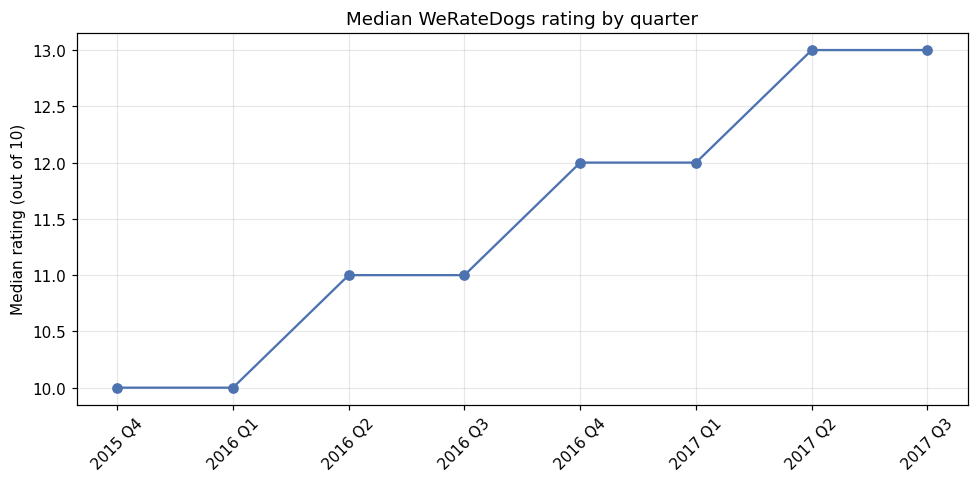

timestamp,2015 Q4,2016 Q1,2016 Q2,2016 Q3,2016 Q4,2017 Q1,2017 Q2,2017 Q3
Median rating,10.0,10.0,11.0,11.0,12.0,12.0,13.0,13.0


In [34]:
rated = master[~master['rating_outlier']].dropna(subset=['rating'])
quarter = rated['timestamp'].dt.year.astype(str) + ' Q' + rated['timestamp'].dt.quarter.astype(str)
quarterly = rated.groupby(quarter)['rating'].median()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(quarterly.index, quarterly.values, marker='o', color='#4c72b0')
ax.set_title('Median WeRateDogs rating by quarter')
ax.set_ylabel('Median rating (out of 10)')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/rating_inflation.png', bbox_inches='tight')
plt.show()
quarterly.to_frame('Median rating').T

The median rating rose steadily from 10/10 in late 2015 to 13/10 by mid-2017. The account's famously generous ratings became even more generous over time, so a rating is only meaningful relative to when it was given.

### 5.2 The most frequently featured breeds

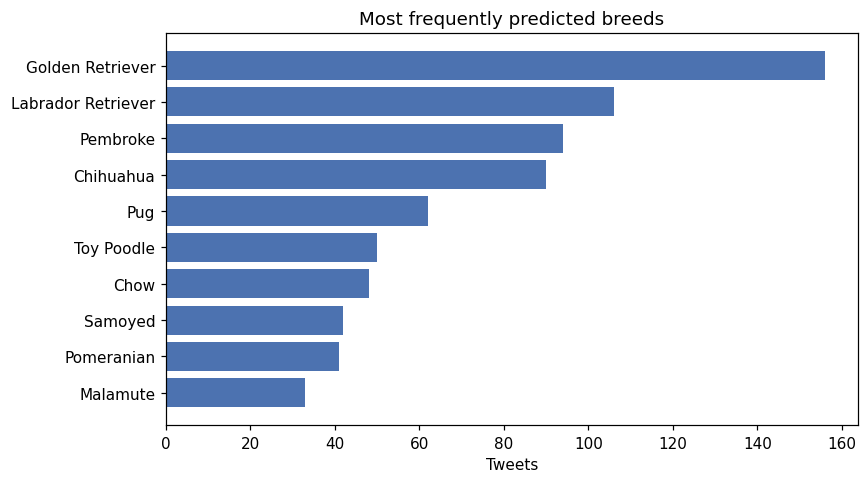

In [35]:
top_breeds = master['breed'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_breeds.index[::-1], top_breeds.values[::-1], color='#4c72b0')
ax.set_title('Most frequently predicted breeds')
ax.set_xlabel('Tweets')
plt.tight_layout()
plt.show()

Golden retrievers are by far the most frequently featured breed, followed by Labrador retrievers, Pembroke Welsh corgis and chihuahuas. These counts rely on the neural network's predictions, so they describe what the model recognised rather than verified breeds.

### 5.3 Which breeds receive the most engagement?

Engagement data is available for 650 tweets posted between July 2016 and August 2017. Favourites and retweets move almost in lockstep, so favourites are used as the engagement measure.

In [36]:
engaged = master.dropna(subset=['favorite_count'])
rho, p = stats.spearmanr(engaged['favorite_count'], engaged['retweet_count'])
print(f"Spearman correlation between favourites and retweets: {rho:.2f} (p = {p:.1e})")

breed_eng = engaged.groupby('breed')['favorite_count'].agg(['count', 'median'])
breed_eng = breed_eng[breed_eng['count'] >= 8].sort_values('median', ascending=False)
breed_eng.head(8)

Spearman correlation between favourites and retweets: 0.90 (p = 2.4e-242)


,count,median
breed,,
Samoyed,17,27052.0
Basset,8,19393.5
French Bulldog,17,19180.0
Chesapeake Bay Retriever,11,17855.0
Pomeranian,9,17417.0
Pembroke,39,16427.0
Cardigan,11,15919.0
Chihuahua,22,14560.5


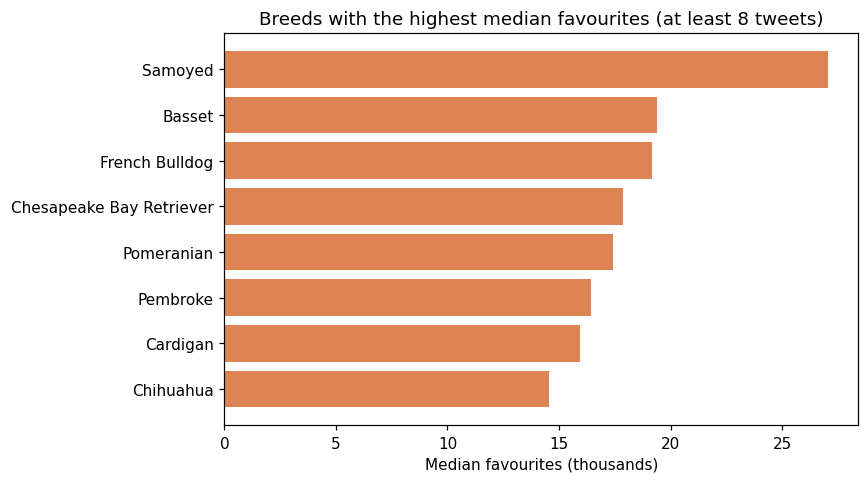

In [37]:
top = breed_eng.head(8)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top.index[::-1], top['median'][::-1] / 1000, color='#dd8452')
ax.set_title('Breeds with the highest median favourites (at least 8 tweets)')
ax.set_xlabel('Median favourites (thousands)')
plt.tight_layout()
plt.savefig('images/breed_engagement.png', bbox_inches='tight')
plt.show()

Samoyeds receive by far the most engagement, with a median of about 27,000 favourites per tweet, well ahead of basset hounds and French bulldogs. The most common breed, the golden retriever, does not appear at the top, which suggests that frequency of appearance and audience enthusiasm are different things. With only 8 to 39 tweets per breed, these rankings are indicative rather than definitive.

### 5.4 Do higher ratings attract more engagement?

In [38]:
eng_rated = engaged[~engaged['rating_outlier']].dropna(subset=['rating']).copy()
rho, p = stats.spearmanr(eng_rated['rating'], eng_rated['favorite_count'])
print(f"Spearman correlation between rating and favourites: {rho:.2f} (p = {p:.1e}), tweets = {len(eng_rated)}")

Spearman correlation between rating and favourites: 0.44 (p = 1.5e-31), tweets = 649


Higher-rated tweets receive more favourites, but both ratings and the account's audience grew over time, so part of this association may simply reflect that later tweets were both rated higher and seen by more followers. A regression of log favourites on the rating that controls for when the tweet was posted separates the two.

In [39]:
eng_rated['days'] = (eng_rated['timestamp'] - eng_rated['timestamp'].min()).dt.days
eng_rated['log_favorites'] = np.log(eng_rated['favorite_count'] + 1)
model = smf.ols('log_favorites ~ rating + days', data=eng_rated).fit(cov_type='HC3')
print(model.summary().tables[1])
print(f"\nOne extra rating point is associated with about {np.expm1(model.params['rating']) * 100:.0f}% more favourites, holding posting date constant.")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.0145      0.297     27.016      0.000       7.433       8.596
rating         0.0756      0.027      2.838      0.005       0.023       0.128
days           0.0033      0.000     14.428      0.000       0.003       0.004

One extra rating point is associated with about 8% more favourites, holding posting date constant.


The rating remains a significant predictor of engagement even after accounting for posting date, so higher-rated dogs do attract more favourites, not merely later ones. This is still an observational association: a dog that is especially appealing may earn both a high rating and many favourites, without the rating itself causing the engagement.

## 6. Conclusions

After cleaning, the master dataset contains 1,971 original tweets with images, of which 650 have engagement data. Cleaning corrected several problems that would have distorted the analysis: retweets and replies were removed, invented names were replaced with missing values, 30 ratings were corrected (including decimal ratings and ratings taken from the wrong fraction), and ratings were standardised to a common scale.

The analysis shows three things. WeRateDogs' ratings inflated steadily, with the median rising from 10/10 to 13/10 in under two years. Golden retrievers appear most often, but Samoyeds attract the most engagement. Higher ratings are associated with more favourites even after controlling for the account's growth over time.

The main limitation is that engagement data covers only a third of the tweets and only the last year of the archive, because many tweets could no longer be retrieved from the API. Breed labels come from an image classifier and may contain errors, and the small number of tweets per breed makes the engagement rankings indicative.